# Data Loading

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib
import json
import os

data = pd.read_csv('/content/Online Retail.csv')

display(data.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


 # Prepare Data

In [13]:
print("Dataset Information:")
print("=" * 60)

data.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12758 entries, 0 to 12757
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    12758 non-null  object 
 1   StockCode    12758 non-null  object 
 2   Description  12713 non-null  object 
 3   Quantity     12758 non-null  int64  
 4   InvoiceDate  12758 non-null  object 
 5   UnitPrice    12758 non-null  float64
 6   CustomerID   9253 non-null   float64
 7   Country      12758 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 797.5+ KB


In [14]:
data.shape

(12758, 8)

In [15]:
data.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [16]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,12758.000000,12758.000000,9253.000000
mean,7.488713,3.943696,15605.690803
std,92.804324,17.056443,1741.432424
min,-9360.000000,0.000000,12395.000000
25%,1.000000,1.250000,14388.000000
50%,2.000000,2.510000,15694.000000
75%,7.000000,4.210000,17198.000000
max,2880.000000,940.870000,18239.000000


In [17]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [18]:
data.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
12753,537395,82600,NO SINGING METAL SIGN,1,12/6/10 14:05,2.10,15356.0,United Kingdom
12754,537395,82599,FANNY'S REST STOPMETAL SIGN,2,12/6/10 14:05,2.10,15356.0,United Kingdom
12755,537395,85152,HAND OVER THE CHOCOLATE SIGN,2,12/6/10 14:05,2.10,15356.0,United Kingdom
12756,537395,22632,HAND WARMER RED RETROSPOT,1,12/6/10 14:05,2.10,15356.0,United Kingdom
12757,537395,21169,YOU'RE CONFUSING ME METAL SIGN,1,12/6/10 14:05,1.69,15356.0,United Ki


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib
import json
import os

from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [20]:
print("Missing Values:")
print("=" * 60)

missing = data.isnull().sum().sort_values(ascending=False)

display(
    pd.DataFrame({
        'Missing Values': missing,
        'Missing %': (missing / len(data) * 100).round(2)
    })
)

Missing Values:


,Missing Values,Missing %
CustomerID,3505,27.47
Description,45,0.35
StockCode,0,0.00
InvoiceNo,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


# Duplicates

In [21]:
duplicate_count = data.duplicated().sum()

print(f"Number of duplicated rows: {duplicate_count:,}")

Number of duplicated rows: 241


In [22]:
data = data.drop_duplicates().copy()

print("Shape after removing duplicates:", data.shape)

Shape after removing duplicates: (12517, 8)


# Convert InvoiceDate

In [24]:
data['InvoiceDate'] = pd.to_datetime(
    data['InvoiceDate'],
    errors='coerce'
)

print(data['InvoiceDate'].dtype)

datetime64[ns]


/tmp/ipykernel_4500/1815050106.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['InvoiceDate'] = pd.to_datetime(


# Missing CustomerID

In [23]:
data = data.dropna(subset=['CustomerID']).copy()

print("Shape:", data.shape)
print("Missing CustomerID:", data['CustomerID'].isna().sum())

Shape: (9012, 8)
Missing CustomerID: 0


In [25]:
data['CustomerID'] = data['CustomerID'].astype(int)

print(data['CustomerID'].dtype)

int64


# Cancellations

In [26]:
data['IsCancelled'] = data['InvoiceNo'].astype(str).str.startswith('C')

print(
    data['IsCancelled']
    .value_counts()
)

IsCancelled
False    8902
True      110
Name: count, dtype: int64


In [27]:
print(
    data['IsCancelled']
    .value_counts(normalize=True) * 100
)

IsCancelled
False   98.78
True     1.22
Name: proportion, dtype: float64


In [32]:
print(sales['InvoiceDate'].dtype)

datetime64[ns]


# RFM features

In [28]:
sales = data[
    (~data['IsCancelled']) &
    (data['Quantity'] > 0) &
    (data['UnitPrice'] > 0)
].copy()

print("Original rows:", len(data))
print("Valid sales rows:", len(sales))

Original rows: 9012
Valid sales rows: 8901


# TotalPrice

In [29]:
sales['TotalPrice'] = (
    sales['Quantity'] * sales['UnitPrice']
)

display(sales.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34


# Reference Date

In [30]:
reference_date = sales['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Last transaction:", sales['InvoiceDate'].max())
print("Reference date:", reference_date)

Last transaction: 2010-12-06 14:05:00
Reference date: 2010-12-07 14:05:00


In [31]:
import pandas as pd
# Ensure the date is converted
data['InvoiceDate'] = pd.to_datetime(
data['InvoiceDate'],
errors='coerce'
)

# Identify cancelled transactions
data['IsCancelled'] = (
data['InvoiceNo']
.astype(str)
.str.startswith('C')
)

# Create a dataset containing only valid sales
sales = data[
(~data['IsCancelled']) &
(data['Quantity'] > 0) &
(data['UnitPrice'] > 0)
].copy()

# Calculate the value of each transaction
sales['TotalPrice'] = (
sales['Quantity'] * sales['UnitPrice']
)

print("Sales shape:", sales.shape)
print("\nSales columns:")
print(sales.columns.tolist())

display(sales.head())

Sales shape: (8901, 10)

Sales columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'IsCancelled', 'TotalPrice']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34


# RFM Feature Engineering

In [33]:
reference_date = (
    sales['InvoiceDate'].max()
    + pd.Timedelta(days=1)
)

print("Last transaction:", sales['InvoiceDate'].max())
print("Reference date:", reference_date)

Last transaction: 2010-12-06 14:05:00
Reference date: 2010-12-07 14:05:00


In [34]:
rfm = sales.groupby('CustomerID').agg(
    Recency=(
        'InvoiceDate',
        lambda x: (reference_date - x.max()).days
    ),

    Frequency=(
        'InvoiceNo',
        'nunique'
    ),

    Monetary=(
        'TotalPrice',
        'sum'
    )
).reset_index()

display(rfm.head())

,CustomerID,Recency,Frequency,Monetary
0,12395,3,1,346.10
1,12427,4,1,303.50
2,12431,6,1,358.25
3,12433,6,1,"1,919.14"
4,12472,1,1,"1,631.30"


In [35]:
print("Number of customers:", len(rfm))

display(rfm.describe())

Number of customers: 356


,CustomerID,Recency,Frequency,Monetary
count,356.00,356.00,356.00,356.00
mean,"15,513.56",3.48,1.32,485.72
std,"1,707.93",1.81,1.91,837.34
min,"12,395.00",1.00,1.00,15.00
25%,"14,140.25",2.00,1.00,183.90
50%,"15,622.50",4.00,1.00,300.03
75%,"16,962.00",5.00,1.00,424.59
max,"18,239.00",6.00,34.00,"9,407.34"


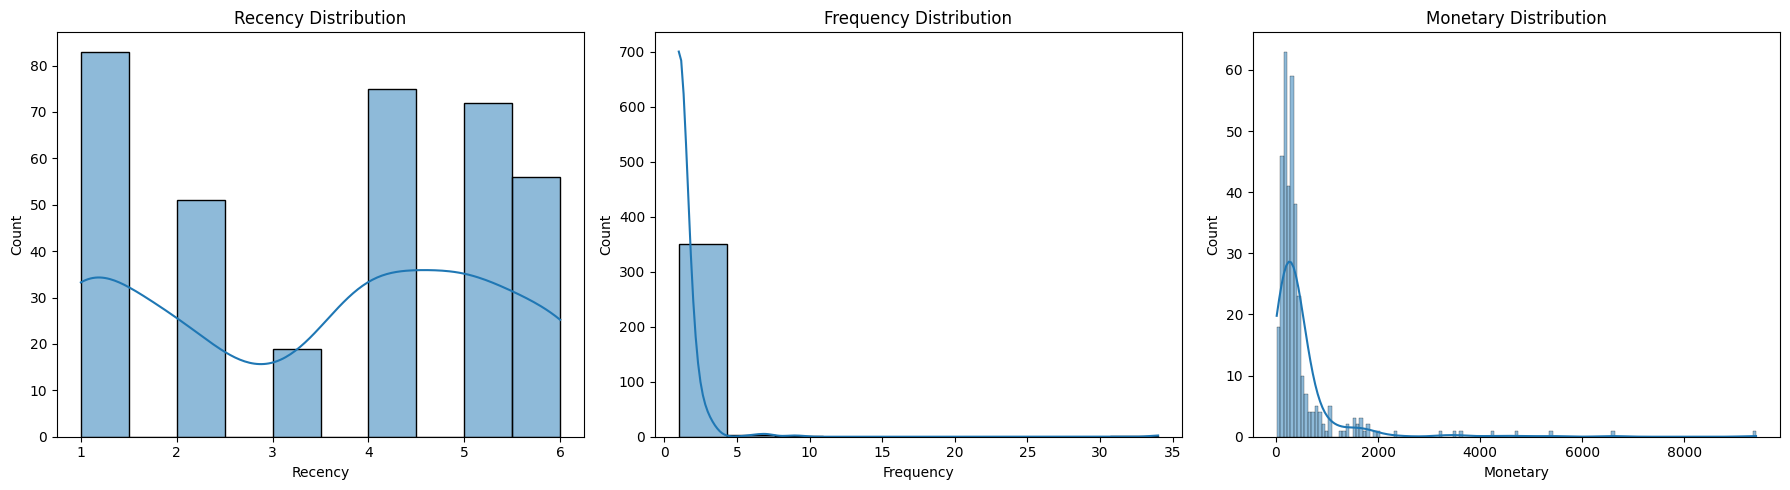

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], kde=True, ax=axes[0])
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], kde=True, ax=axes[1])
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], kde=True, ax=axes[2])
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

# Outlier Detection

In [37]:
def cap_outliers_iqr(df, columns):
    df = df.copy()

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower, upper)

    return df

# Log Transformation

In [38]:
rfm_model_data = cap_outliers_iqr(
    rfm,
    ['Recency', 'Frequency', 'Monetary']
)

display(rfm_model_data.describe())

,CustomerID,Recency,Frequency,Monetary
count,356.00,356.00,356.00,356.00
mean,"15,513.56",3.48,1.00,338.67
std,"1,707.93",1.81,0.00,214.58
min,"12,395.00",1.00,1.00,15.00
25%,"14,140.25",2.00,1.00,183.90
50%,"15,622.50",4.00,1.00,300.03
75%,"16,962.00",5.00,1.00,424.59
max,"18,239.00",6.00,1.00,785.62


In [39]:
rfm_features = rfm_model_data[
    ['Recency', 'Frequency', 'Monetary']
].copy()

rfm_log = np.log1p(rfm_features)

display(rfm_log.head())

,Recency,Frequency,Monetary
0,1.39,0.69,5.85
1,1.61,0.69,5.72
2,1.95,0.69,5.88
3,1.95,0.69,6.67
4,0.69,0.69,6.67


# StandardScaler

In [40]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm_log.index
)

display(rfm_scaled.head())

,Recency,Frequency,Monetary
0,-0.03,0.00,0.34
1,0.45,0.00,0.15
2,1.17,0.00,0.39
3,1.17,0.00,1.51
4,-1.52,0.00,1.51


# kmeans - Clusters

In [41]:
inertia = []

K_RANGE = range(2, 11)

for k in K_RANGE:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

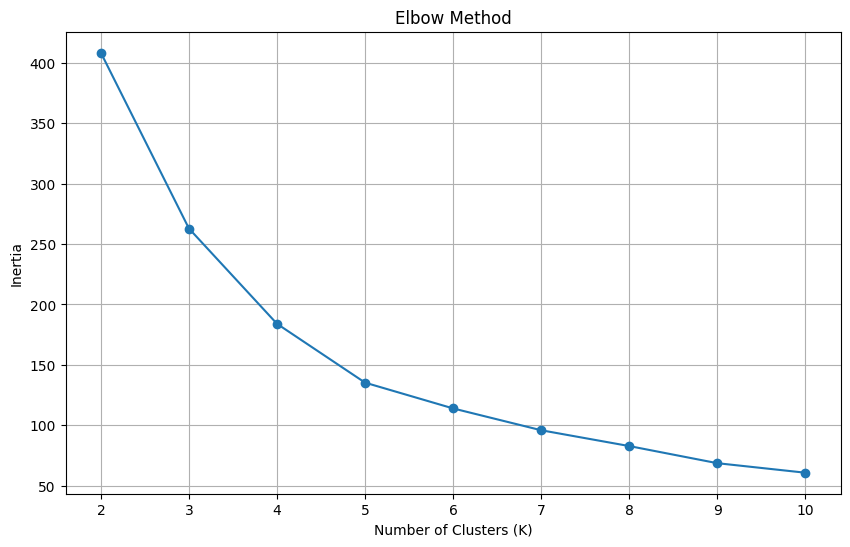

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(
    K_RANGE,
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.xticks(list(K_RANGE))
plt.grid(True)

plt.show()

# Silhouette Score

In [43]:
silhouette_scores = {}

for k in K_RANGE:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores[k] = score

    print(
        f"K={k} | Silhouette Score={score:.4f}"
    )

K=2 | Silhouette Score=0.4475
K=3 | Silhouette Score=0.4237
K=4 | Silhouette Score=0.4305
K=5 | Silhouette Score=0.4487
K=6 | Silhouette Score=0.4450
K=7 | Silhouette Score=0.4596
K=8 | Silhouette Score=0.4609
K=9 | Silhouette Score=0.4441
K=10 | Silhouette Score=0.4505


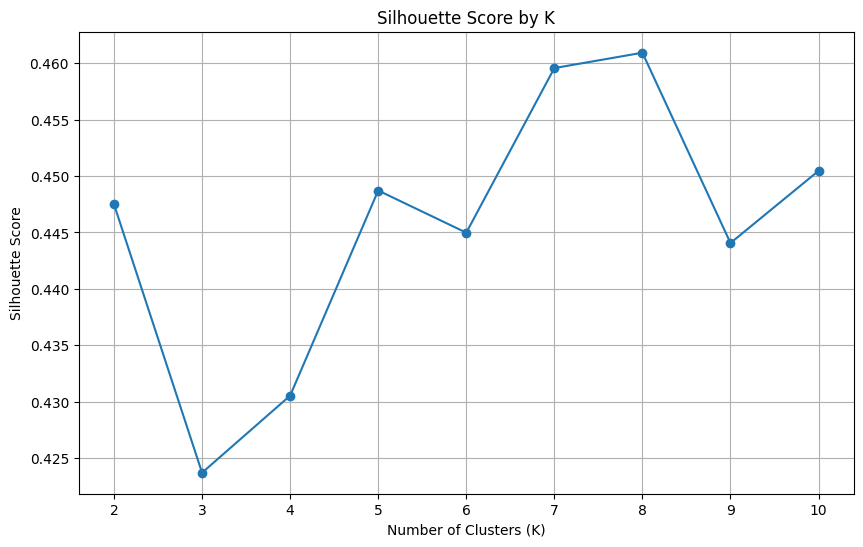

In [44]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K')

plt.grid(True)

plt.show()

In [45]:
OPTIMAL_K = 3

kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=20
)

rfm_model_data['Cluster'] = kmeans.fit_predict(rfm_scaled)

display(rfm_model_data.head())

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12395,3,1,346.10,1
1,12427,4,1,303.50,1
2,12431,6,1,358.25,1
3,12433,6,1,785.62,1
4,12472,1,1,785.62,2


In [46]:
cluster_counts = (
    rfm_model_data['Cluster']
    .value_counts()
    .sort_index()
)

display(cluster_counts)

,count
Cluster,
0,87
1,142
2,127


# Cluster Profiling

In [47]:
cluster_profile = rfm_model_data.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

display(cluster_profile)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,87,4.38,1.00,136.69
1,142,4.81,1.00,442.36
2,127,1.37,1.00,361.11


In [48]:
cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,87,4.38,1.00,136.69
1,142,4.81,1.00,442.36
2,127,1.37,1.00,361.11


In [49]:
segment_mapping = {
    0: 'At Risk Customers',
    1: 'Loyal Customers',
    2: 'High Value Customers'
}

In [50]:
rfm_model_data['Segment'] = (
    rfm_model_data['Cluster']
    .map(segment_mapping)
)

display(
    rfm_model_data[
        ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']
    ].head()
)

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12395,3,1,346.10,1,Loyal Customers
1,12427,4,1,303.50,1,Loyal Customers
2,12431,6,1,358.25,1,Loyal Customers
3,12433,6,1,785.62,1,Loyal Customers
4,12472,1,1,785.62,2,High Value Customers


# Visualization

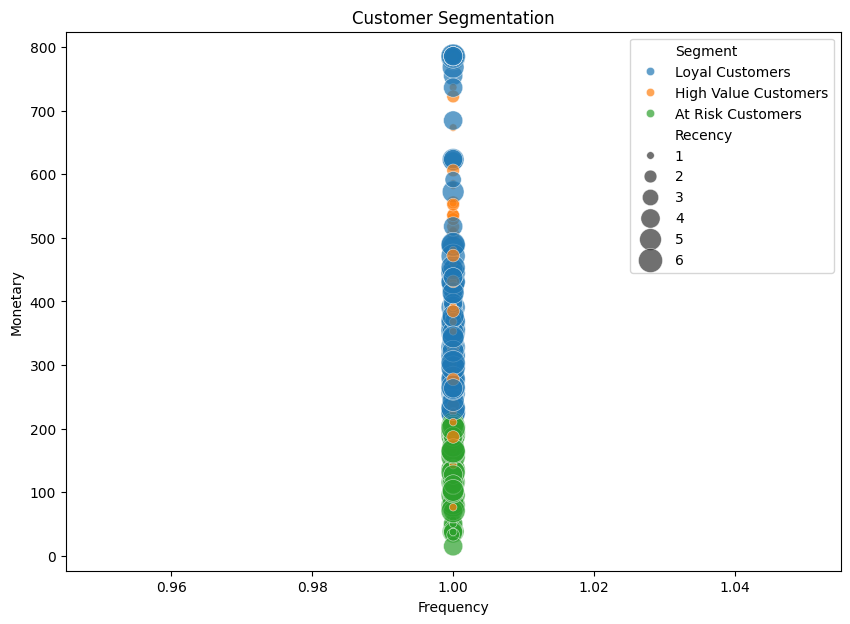

In [51]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm_model_data,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    size='Recency',
    sizes=(30, 300),
    alpha=0.7
)

plt.title('Customer Segmentation')
plt.xlabel('Frequency')
plt.ylabel('Monetary')

plt.show()

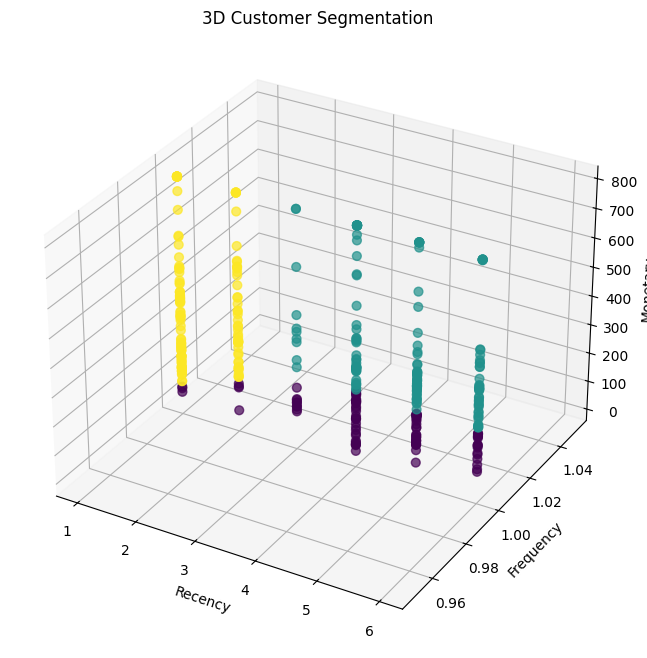

In [52]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    rfm_model_data['Recency'],
    rfm_model_data['Frequency'],
    rfm_model_data['Monetary'],
    c=rfm_model_data['Cluster'],
    s=40,
    alpha=0.7
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

ax.set_title('3D Customer Segmentation')

plt.show()

# Saving

In [53]:
OUTPUT_DIR = '/content/artifacts'

os.makedirs(OUTPUT_DIR, exist_ok=True)

rfm_model_data.to_csv(
    f'{OUTPUT_DIR}/rfm_customers.csv',
    index=False
)

print("RFM customer dataset saved.")

RFM customer dataset saved.


In [54]:
cluster_profile.to_csv(
    f'{OUTPUT_DIR}/cluster_profiles.csv'
)

print("Cluster profiles saved.")

Cluster profiles saved.


In [55]:
with open(
    f'{OUTPUT_DIR}/segment_mapping.json',
    'w',
    encoding='utf-8'
) as f:

    json.dump(
        segment_mapping,
        f,
        ensure_ascii=False,
        indent=4
    )

print("Segment mapping saved.")

Segment mapping saved.


In [56]:
model_artifacts = {
    'model': kmeans,
    'scaler': scaler,
    'features': [
        'Recency',
        'Frequency',
        'Monetary'
    ],
    'transformation': 'log1p',
    'reference_date': reference_date,
    'segment_mapping': segment_mapping
}

joblib.dump(
    model_artifacts,
    f'{OUTPUT_DIR}/customer_segmentation_pipeline.joblib'
)

print("Model artifacts saved successfully.")

Model artifacts saved successfully.


In [57]:
model_path = (
    f'{OUTPUT_DIR}/customer_segmentation_pipeline.joblib'
)

loaded_artifacts = joblib.load(model_path)

print(loaded_artifacts.keys())

dict_keys(['model', 'scaler', 'features', 'transformation', 'reference_date', 'segment_mapping'])


In [58]:
new_customer = pd.DataFrame({
    'Recency': [20],
    'Frequency': [15],
    'Monetary': [2500]
})

new_customer_log = np.log1p(new_customer)

new_customer_scaled = loaded_artifacts['scaler'].transform(
    new_customer_log
)

cluster = loaded_artifacts['model'].predict(
    new_customer_scaled
)[0]

segment = loaded_artifacts['segment_mapping'].get(
    str(cluster),
    loaded_artifacts['segment_mapping'].get(cluster, 'Unknown')
)

print("Predicted Cluster:", cluster)
print("Predicted Segment:", segment)

Predicted Cluster: 1
Predicted Segment: Loyal Customers


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [59]:
!ls -lh /content/artifacts

total 28K
-rw-r--r-- 1 root root  122 Sep 13 08:44 cluster_profiles.csv
-rw-r--r-- 1 root root 3.4K Sep 13 08:44 customer_segmentation_pipeline.joblib
-rw-r--r-- 1 root root  14K Sep 13 08:44 rfm_customers.csv
-rw-r--r-- 1 root root   93 Sep 13 08:44 segment_mapping.json


In [60]:
!zip -r /content/customer_segmentation_artifacts.zip /content/artifacts

  adding: content/artifacts/ (stored 0%)
  adding: content/artifacts/cluster_profiles.csv (deflated 16%)
  adding: content/artifacts/customer_segmentation_pipeline.joblib (deflated 63%)
  adding: content/artifacts/rfm_customers.csv (deflated 79%)
  adding: content/artifacts/segment_mapping.json (deflated 35%)
